In [40]:
%pip install --upgrade kaleido


   ------------------------ --------------- 3/5 [choreographer]
   ---------------------------------------- 5/5 [kaleido]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
# 1. Leer el archivo dos veces : una con pd.read_csv normal y otra con dtype={"ubigeo": str}. 
# Muestren la diferencia y expliquen en una celda de texto por qué importa. 

import pandas as pd

pd.read_csv ("datos/ubigeo.csv")

,ubigeo,departamento
0,1,Amazonas
1,2,Áncash
2,3,Apurímac
3,4,Arequipa
4,5,Ayacucho
5,6,Cajamarca
6,7,Callao
7,8,Cusco
8,9,Huancavelica
9,10,Huánuco


In [2]:
ubigeo = pd.read_csv("datos/ubigeo.csv", dtype={"ubigeo": str})
print(ubigeo)

   ubigeo   departamento
0      01       Amazonas
1      02         Áncash
2      03       Apurímac
3      04       Arequipa
4      05       Ayacucho
5      06      Cajamarca
6      07         Callao
7      08          Cusco
8      09   Huancavelica
9      10        Huánuco
10     11            Ica
11     12          Junín
12     13    La Libertad
13     14     Lambayeque
14     15           Lima
15     16         Loreto
16     17  Madre de Dios
17     18       Moquegua
18     19          Pasco
19     20          Piura
20     21           Puno
21     22     San Martín
22     23          Tacna
23     24         Tumbes
24     25        Ucayali


La diferencia es que al incorporar el dtype no se borran los ceros iniciales del ubigeo.

In [3]:
# 2. Agregar el ubigeo a decretos_por_departamento.csv y a lluvias_por_departamento.csv.
import pandas as pd 

decretos = pd.read_csv("datos/decretos_por_departamento.csv", encoding="utf-8-sig")
decretos = decretos.merge(ubigeo, on="departamento", how="left", validate="one_to_one")
decretos = decretos[["ubigeo", "departamento","declaratorias","prorrogas"]]
print(decretos)


   ubigeo   departamento  declaratorias  prorrogas
0      01       Amazonas              1          0
1      02         Áncash              0          0
2      03       Apurímac              0          0
3      04       Arequipa              0          0
4      05       Ayacucho              1          0
5      06      Cajamarca              0          0
6      07         Callao              0          0
7      08          Cusco              0          0
8      09   Huancavelica              0          0
9      10        Huánuco              0          0
10     11            Ica              0          0
11     12          Junín              0          0
12     13    La Libertad              0          0
13     14     Lambayeque              0          0
14     15           Lima              0          0
15     16         Loreto              0          0
16     17  Madre de Dios              0          0
17     18       Moquegua              0          0
18     19          Pasco       

In [4]:
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv", sep=";", encoding="utf-8-sig")
lluvias = lluvias.merge(ubigeo, on="departamento", how="left", validate="one_to_one")
lluvias = lluvias[["ubigeo", "departamento","capital","latitud", "longitud", "lluvia_total_mm", "dias_lluvia_fuerte"]]
print(lluvias)

   ubigeo   departamento           capital   latitud  longitud  \
0      01       Amazonas       Chachapoyas  -6.23169 -77.86903   
1      02         Áncash            Huaraz  -9.52614 -77.52869   
2      03       Apurímac           Abancay -13.63426 -72.88380   
3      04       Arequipa          Arequipa -16.39899 -71.53747   
4      05       Ayacucho          Ayacucho -13.16380 -74.22345   
5      06      Cajamarca         Cajamarca  -7.16378 -78.50027   
6      08          Cusco             Cusco -13.53188 -71.96701   
7      09   Huancavelica      Huancavelica -12.78691 -74.97298   
8      10        Huánuco           Huánuco  -9.92882 -76.23989   
9      11            Ica               Ica -14.07538 -75.73422   
10     12          Junín          Huancayo -12.06866 -75.21027   
11     13    La Libertad          Trujillo  -8.11599 -79.02998   
12     14     Lambayeque          Chiclayo  -6.77008 -79.85495   
13     15           Lima              Lima -12.04318 -77.02824   
14     16 

4. Verificación: muestren qué departamentos no encontraron su ubigeo en cada tabla (por ejemplo, por tildes o nombres escritos distinto). Corríjanlos hasta que no quede ninguno.

No se generó ningún error al hacer el merge. 

In [5]:
# Cruzar las dos tablas por ubigeo

unificada = decretos.merge(
    lluvias.drop(columns="departamento"),
    on="ubigeo",
    how="outer",
    validate="one_to_one",
    indicator=True,
)

unificada = unificada[["ubigeo", "departamento", "capital", "latitud", "longitud",
               "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]]
print(unificada)

   ubigeo   departamento           capital   latitud  longitud  \
0      01       Amazonas       Chachapoyas  -6.23169 -77.86903   
1      02         Áncash            Huaraz  -9.52614 -77.52869   
2      03       Apurímac           Abancay -13.63426 -72.88380   
3      04       Arequipa          Arequipa -16.39899 -71.53747   
4      05       Ayacucho          Ayacucho -13.16380 -74.22345   
5      06      Cajamarca         Cajamarca  -7.16378 -78.50027   
6      07         Callao            Callao -12.05162 -77.13452   
7      08          Cusco             Cusco -13.53188 -71.96701   
8      09   Huancavelica      Huancavelica -12.78691 -74.97298   
9      10        Huánuco           Huánuco  -9.92882 -76.23989   
10     11            Ica               Ica -14.07538 -75.73422   
11     12          Junín          Huancayo -12.06866 -75.21027   
12     13    La Libertad          Trujillo  -8.11599 -79.02998   
13     14     Lambayeque          Chiclayo  -6.77008 -79.85495   
14     15 

6. Verificación: la tabla final debe tener 25 filas. Los departamentos sin ninguna declaratoria deben aparecer con 0, no desaparecer.

Se verifica el cruce correcto de la información 

In [6]:
# Guardar datos/tabla_final.csv. El ubigeo debe quedar como texto de 2 dígitos (01, no 1).

unificada.to_csv("datos/tabla-final.csv", index=False, encoding="utf-8-sig")

In [14]:
data = pd.read_csv("datos/tabla-final.csv", dtype={"ubigeo":str})
data = data.sort_values("lluvia_total_mm").reset_index(drop=True)
print(data)

   ubigeo   departamento           capital   latitud  longitud  \
0      23          Tacna             Tacna -18.01465 -70.25362   
1      18       Moquegua          Moquegua -17.19747 -70.93587   
2      11            Ica               Ica -14.07538 -75.73422   
3      07         Callao            Callao -12.05162 -77.13452   
4      15           Lima              Lima -12.04318 -77.02824   
5      20          Piura             Piura  -5.18192 -80.65715   
6      14     Lambayeque          Chiclayo  -6.77008 -79.85495   
7      13    La Libertad          Trujillo  -8.11599 -79.02998   
8      04       Arequipa          Arequipa -16.39899 -71.53747   
9      24         Tumbes            Tumbes  -3.55592 -80.44258   
10     01       Amazonas       Chachapoyas  -6.23169 -77.86903   
11     10        Huánuco           Huánuco  -9.92882 -76.23989   
12     05       Ayacucho          Ayacucho -13.16380 -74.22345   
13     08          Cusco             Cusco -13.53188 -71.96701   
14     03 

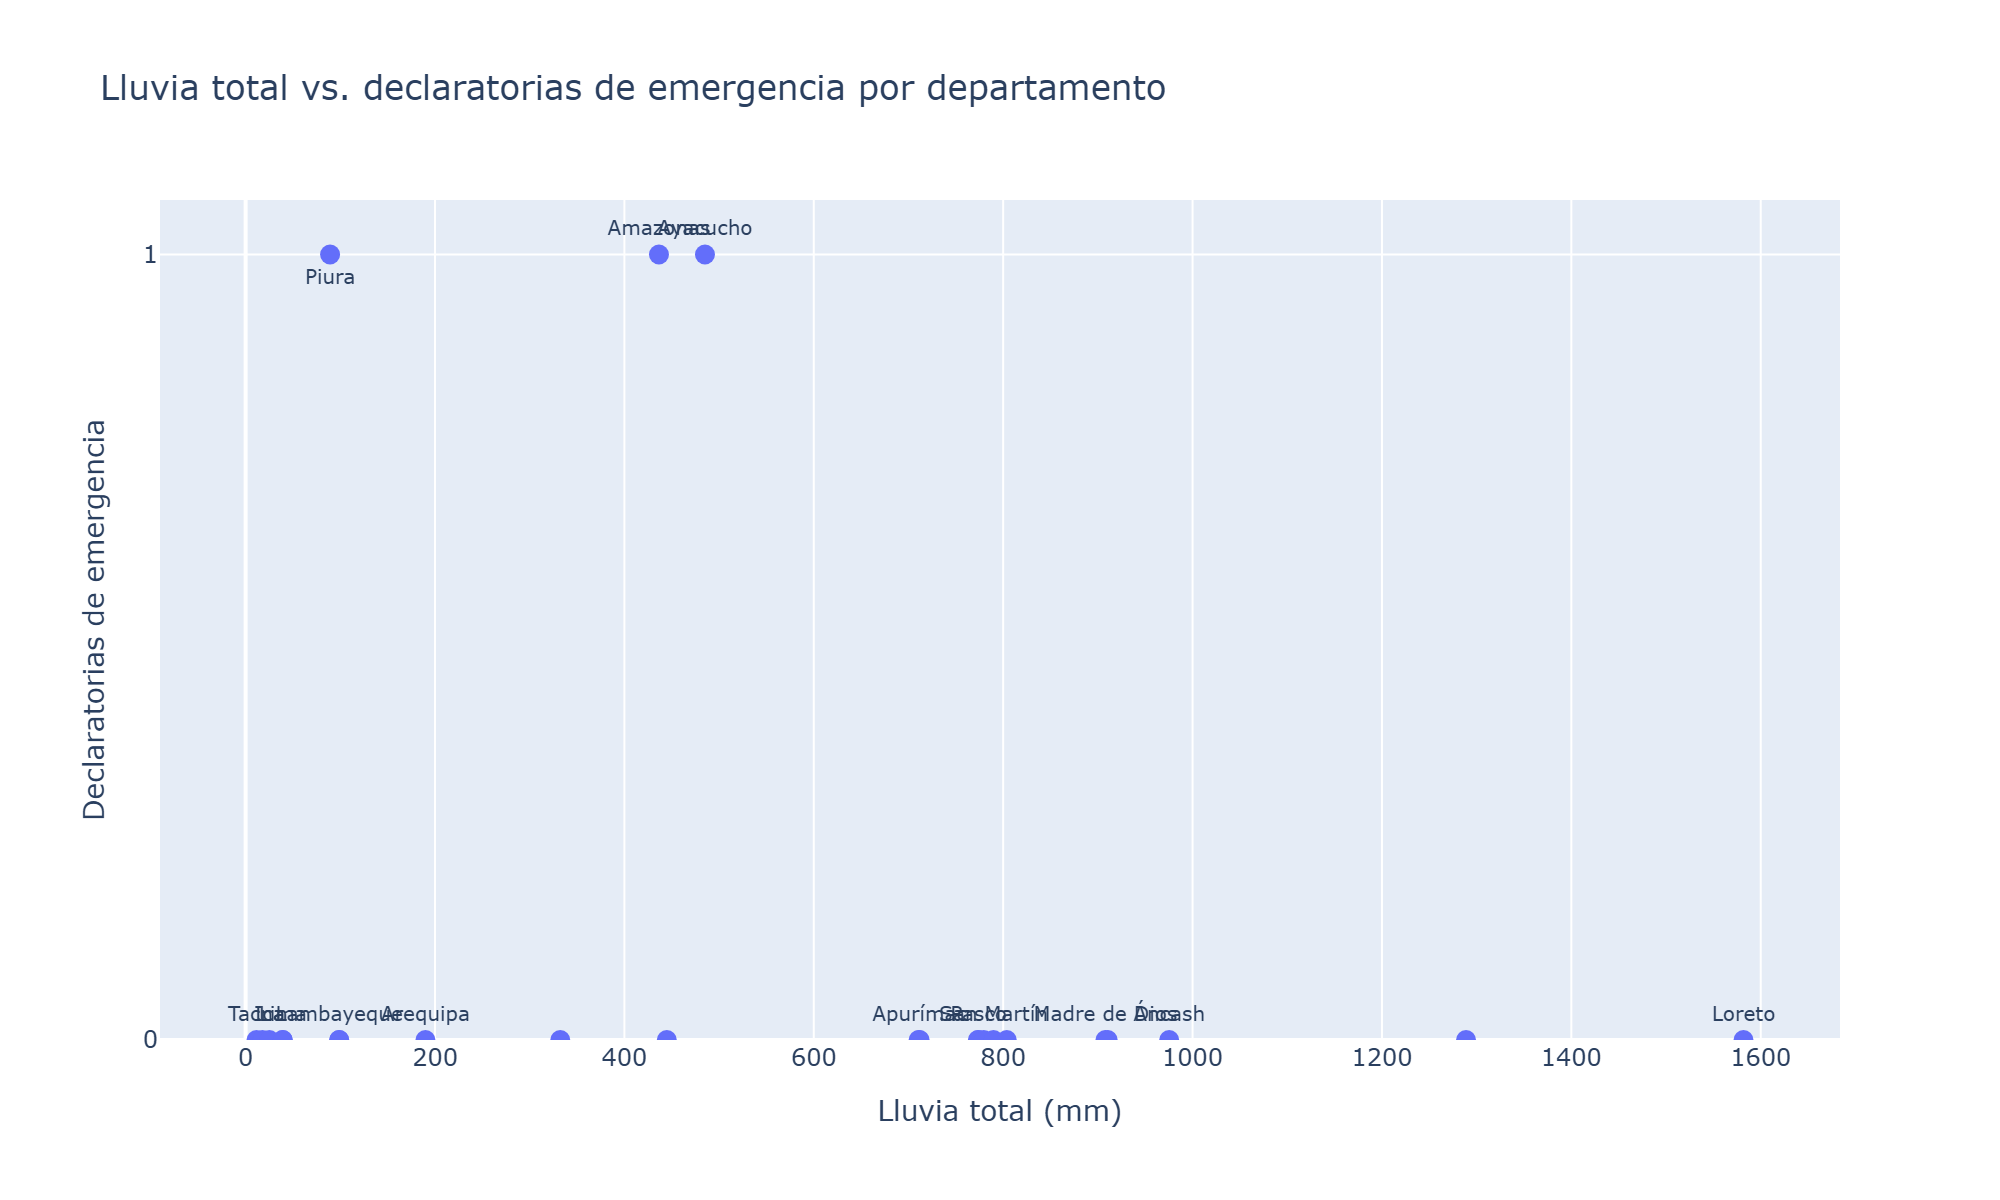

In [13]:
# Con Plotly, hacer dos gráficos:
# 1. un gráfico de dispersión con lluvia_total_mm en el eje X, declaratorias en el eje Y y el nombre del departamento en cada punto;
# 2. un gráfico de barras con los 10 departamentos con más declaratorias.

import plotly.express as px
import plotly.io as pio

data = pd.read_csv("datos/tabla-final.csv", dtype={"ubigeo":str})
data = data.sort_values("lluvia_total_mm").reset_index(drop=True)
posiciones = ["top center", "bottom center"]
data["pos_texto"] = [posiciones[i % 2] for i in range(len(data))]

fig = px.scatter(
    data,
    x="lluvia_total_mm",
    y="declaratorias",
    text="departamento",
    hover_data=["capital", "dias_lluvia_fuerte", "prorrogas"],
    labels={
        "lluvia_total_mm": "Lluvia total (mm)",
        "declaratorias": "Declaratorias de emergencia",
        "departamento": "Departamento",
    },
    title="Lluvia total vs. declaratorias de emergencia por departamento",
)

fig.update_traces(
    textposition=data["pos_texto"],
    textfont_size=10,
    marker=dict(size=10),
)
fig.update_yaxes(dtick=1, rangemode="tozero")
fig.update_layout(height=600)

fig.show(renderer="png", width=1000, height=600, scale=2)

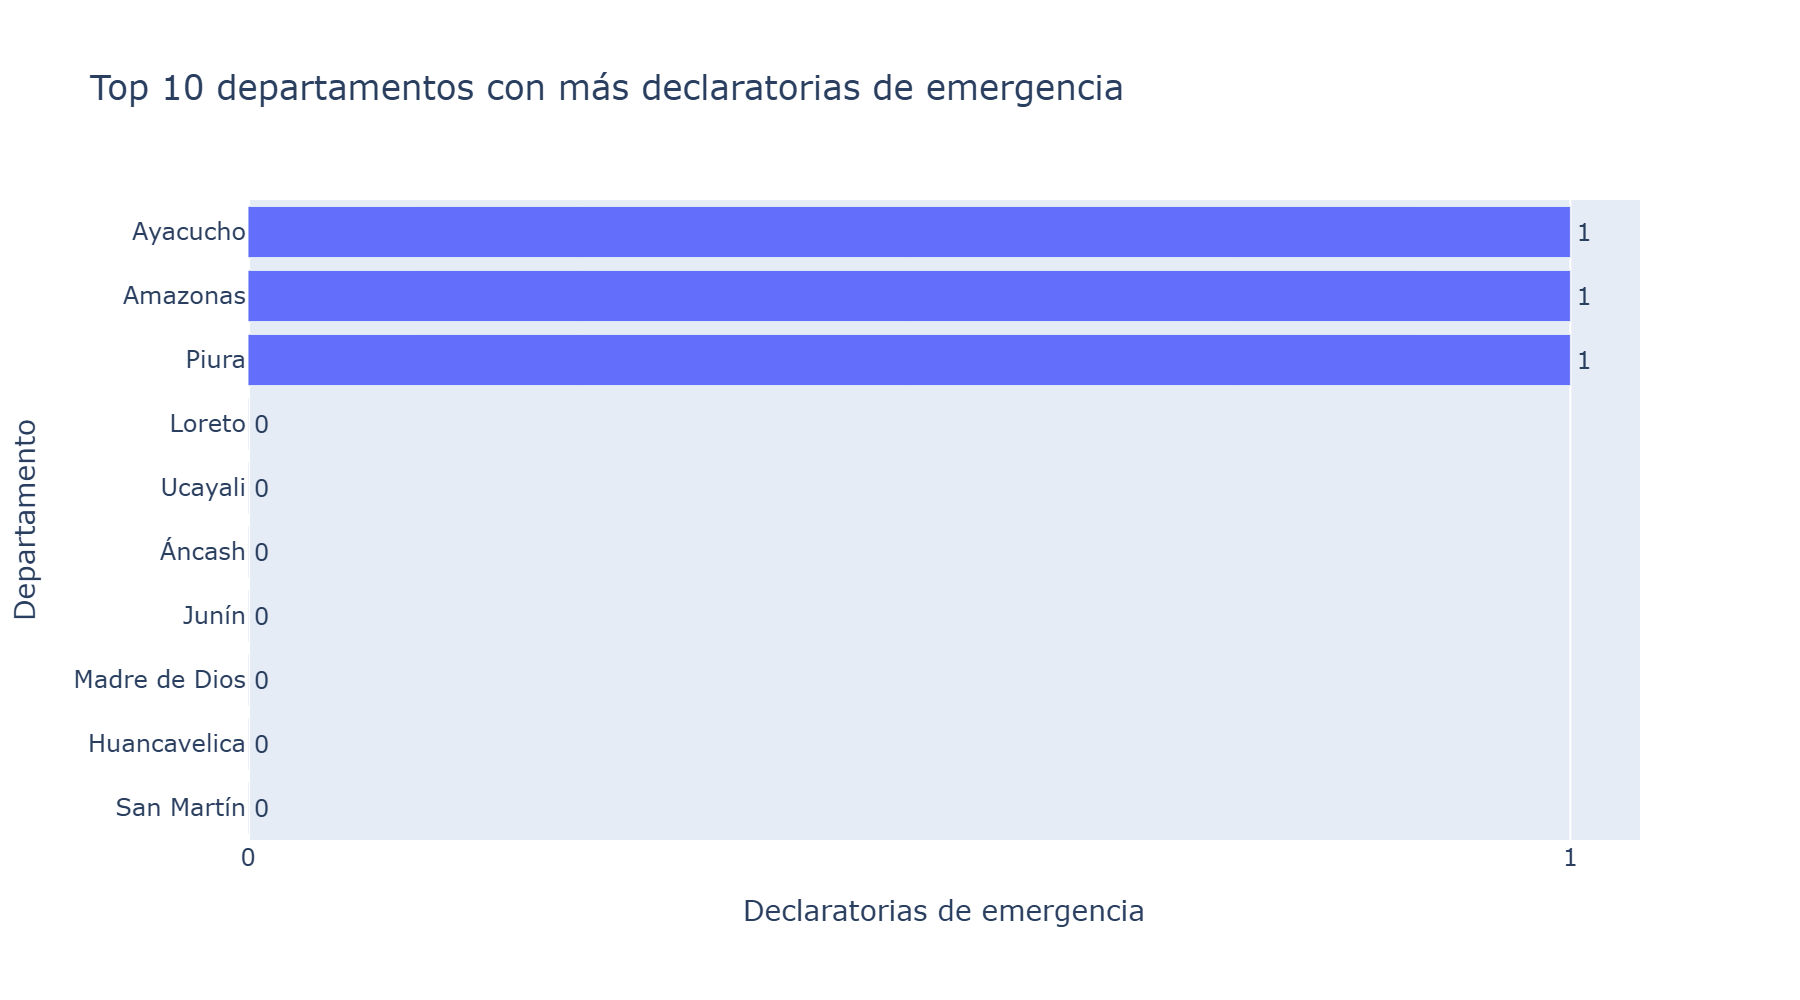

In [12]:
top = data.sort_values(["declaratorias","lluvia_total_mm"], ascending=False).head(10)

fig = px.bar(
    top,
    x="declaratorias",
    y="departamento",
    orientation="h",
    text="declaratorias",
    hover_data=["lluvia_total_mm", "prorrogas"],
    labels={
        "declaratorias": "Declaratorias de emergencia",
        "departamento": "Departamento",
        "lluvia_total_mm": "Lluvia total (mm)",
    },
    title="Top 10 departamentos con más declaratorias de emergencia",
)

fig.update_traces(textposition="outside")
fig.update_yaxes(categoryorder="array", categoryarray=top["departamento"][::-1]) 
fig.update_xaxes(dtick=1, rangemode="tozero")
fig.update_layout(height=500)
fig.show(renderer="png", width=900, height=500, scale=2)

Responder lo siguiente: 

1. ¿Cuáles fueron los 3 departamentos con más declaratorias? ¿Coinciden con los 3 donde más llovió?

Para los meses de enero a mayo de 2022 solo se encontró una declaratoria de emergencia por lluvias para los departamentos de Ayacucho, Amazonas y Piura. Sin embargo, los departamentos donde más llovió fueron Loreto (1581.8 mm), Ucayali (1288.8) y Áncash (975.3).

2. ¿Hay departamentos con mucha lluvia y pocas o ninguna declaratoria, o al revés? Den al menos dos razones posibles.

Si, la gran mayoría de los departamentos tuvo mayor cantidad de lluvia que los tres departamentos con declaratoria. La cantidad de lluvia que pueda haber en un departamento no es una causa directa para emitir declaratorias de emergencia. Estas se emiten de acuerdo al impacto en daños que genera en el departamento, producto de lo atípica que pueda ser para ese territorio. 

3. ¿Qué porcentaje de las declaratorias fue por peligro inminente (antes del daño) y qué porcentaje por impacto de daños (después)? ¿Qué dice eso sobre la gestión del riesgo en su temporada?

El 100% fue por impacto de daños. Eso signfica que la gestión del riesgo de desastres es reactiva, una vez ocurrido el daño. 

4. Mencionen al menos tres limitaciones de este análisis.

- El análisis de las lluviass se hizo en la capital de departamento, lo cual no necesariamente representa lo ocurrido en las zonas donde hubo daños para emitir una declaratoria de emergencia. 
- La cantidad de lluvia no implica causalidad para emisión de declaratorias de emergencias.
- Solo se está midiendo un periodo de 6 meses, para evaluar si la implementación del mecanismo de declaratorias con relación a las lluvias, tendría que evaluarse un periodo más largo de tiempo. 

Conclusión: respondan la pregunta del trabajo en 5 a 8 líneas

- Para el periodo de enero a mayo del 2022 no se encontró una relación clara entre la cantidad de lluvia en mm que cayó en un departamento y la emisión de declaratorias de emergencia. Solo tres departamentos: Amazonas, Ayacucho y Piura recibieron una declaratoria de emergencia y ninguno se situa entre los más lluviosos. Aquellos donde si hubo mayor lluvia, no recibieron ningún mecanismo de emergencia. Esto indica que las declaratorias de emergencia no se implementan por el volúmen de lluvia sino por daño o impacto generado por este en la población o en el territorio. Adicionalmente, la declaratoria de emergencia para los tres departamentos señalados fue reactiva, lo que sugiere una limitada capacidad del Estado Peruano en la prevención del riesgo. 